### RNN predicting temperature

Using Recurrent Neural Networks (RNN) with PyTorch
**Objective**: The goal of this project is to build a time-series forecasting model that predicts the minimum temperature of the next day
based on a sequence of past temperatures.
**Dataset**:
- Source: Daily minimum temperatures in Melbourne, Australia (1981-1990).
- Features: Date and Temperature (*C).
- Task: Univariate Time Series

### Imports and loading data

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
import torch.nn as nn

import warnings
warnings.filterwarnings('ignore')

In [6]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'

df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [7]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB


In [8]:
df.describe()

,Temp
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


In [9]:
df.isna().sum()

Temp    0
dtype: int64

### Visualising dataset

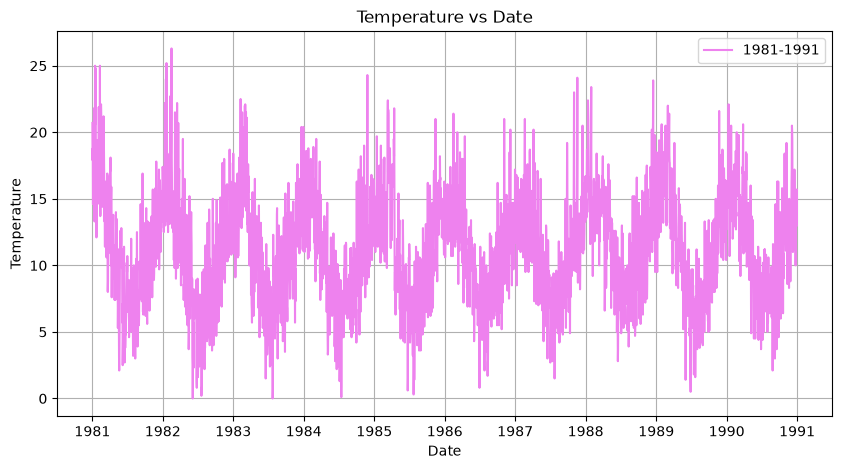

In [20]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Temp'], label='1981-1991', color='violet')

plt.title('Temperature vs Date')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid()
plt.show()

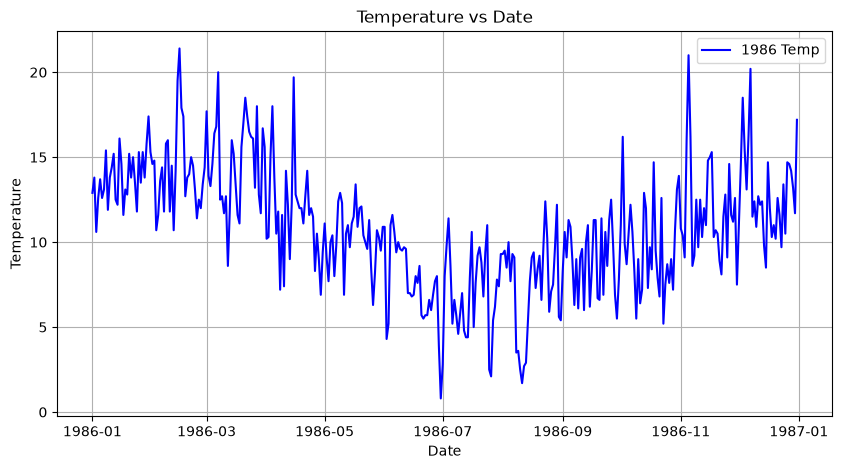

In [17]:
plt.figure(figsize=(10,5))
plt.plot(df.loc['1986'].index, df.loc['1986']['Temp'], label='1986 Temp', color='blue')

plt.title('Temperature vs Date')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid()
plt.show()

## Train test approach
With sequential data (time series), randomly splitting for train test might not be the best approach, this can result in look-ahead bias, since model has information about the future. The solution is splitting by time.

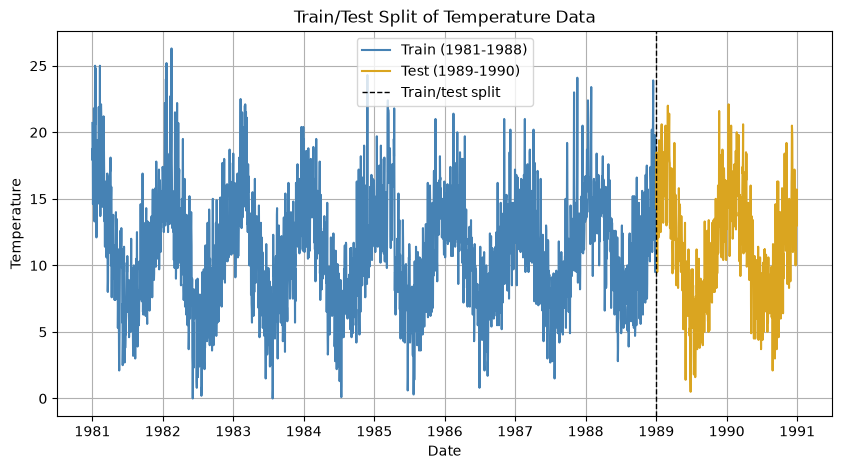

Train: 2920 obs (80%), Test: 730 obs (20%)


In [23]:
train = df.loc[:'1988']
test = df.loc['1989':]

plt.figure(figsize=(10, 5))
plt.plot(train.index, train['Temp'], label='Train (1981-1988)', color='steelblue')
plt.plot(test.index, test['Temp'], label='Test (1989-1990)', color='goldenrod')
plt.axvline(test.index[0], color='black', linestyle='--', linewidth=1, label='Train/test split')

plt.title('Train/Test Split of Temperature Data')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid()
plt.show()

print(f'Train: {len(train)} obs ({len(train)/len(df):.0%}), Test: {len(test)} obs ({len(test)/len(df):.0%})')

## Data preprocessing

In [26]:
# split done already for the train test
# train = df.loc[:'1988']
# test = df.loc['1989':]

print(f'Training samples: {train.shape[0]}, Test samples: {test.shape[0]}')

Training samples: 2920, Test samples: 730


#### Scaling
Fit the scaler only on training data to prevent data leakage

In [29]:
scaler = MinMaxScaler(feature_range=(-1, 1))

train_data_normalised = scaler.fit_transform(train['Temp'].values.reshape(-1, 1))
test_data_normalised = scaler.transform(test['Temp'].values.reshape(-1, 1))

#### Convert to PyTorch Tensors

In [31]:
train_data_normalised = torch.FloatTensor(train_data_normalised).view(-1)
test_data_normalised = torch.FloatTensor(test_data_normalised).view(-1)

## Data preparation --> Sliding window
RNNs requires input data in the form of sequences, not individual points. Sliding widow approach is used to transform the time series.<br>
- Window size $(N)$: 30 days
- Input $(X)$: Temperatures from $t$ to $t + 29$
- Target $(y)$: Temperature at $t + 30$
This effectively turns the time series into a supervised learning problem.

$$
\begin{aligned}
\left[d_1, d_2, \dots, d_{30}\right] &\rightarrow \text{predict } d_{31} \\
\left[d_2, d_3, \dots, d_{31}\right] &\rightarrow \text{predict } d_{32}
\end{aligned}
$$

In [32]:
# tw - train window set up in next cell
def create_inout_sequences(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(L-tw):
        # sequence of length tw
        train_seq = input_data[i:i+tw]

        # single target value just after the sequence
        train_label = input_data[i+tw:i+tw+1]

        inout_seq.append((train_seq, train_label))
    return inout_seq

In [33]:
# define window size (N)
train_window = 30
train_inout_seq = create_inout_sequences(train_data_normalised, train_window)
test_inout_seq = create_inout_sequences(test_data_normalised, train_window)

print(f'Total training sequences created: {len(train_inout_seq)})')

Total training sequences created: 2890)


In [40]:
# checking first sequence
example_seq, example_label = train_inout_seq[0]
print(f'Example sequence: {example_seq}')
print(f'Example label: {example_label}')
print('')
print(f'Example sequence: {example_seq.shape}, Example label: {example_label.shape}') # should print torch.Size([30]), torch.Size([1])

Example sequence: tensor([ 0.5741,  0.3612,  0.4297,  0.1103,  0.2015,  0.2015,  0.2015,  0.3232,
         0.6578,  0.5209,  0.2319,  0.0114,  0.2700,  0.6350,  0.9011,  0.5741,
         0.5665,  0.8859,  0.3460,  0.1787,  0.3840, -0.0798,  0.0951,  0.2167,
         0.2548,  0.4221,  0.4753,  0.3080,  0.1787,  0.1483])
Example label: tensor([0.1711])

Example sequence: torch.Size([30]), Example label: torch.Size([1])


## Model architecture
Define a custom class `TemperatureRNN` inheriting from `nn.Module`.

**Architecture Breakdown:**

1. **Input Layer:** Accepts tensors of shape `(Batch_Size, Sequence_Length, 1)`.
2. **RNN Layer:** The core recurrent layer that maintains a "hidden state" (memory) as it processes the sequence day by day.
    - `hidden_size=64`: The capacity of the network's memory.
3. **Fully Connected Layer (Linear):** Takes the final hidden state output by the RNN and maps it to a single value (the predicted temperature).

In [46]:
class TemperatureRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super(TemperatureRNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # RNN layer
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)

        # fully connected layer
        self.linear = nn.Linear(hidden_size, output_size)

def forward(self, x):
    # explicitly move h0 to the same device as input x
    h0 = torch.zeros(1, x.size(0), self.hidden_size)

    # forward propagate RNN
    out, _ = self.rnn(x, h0)

    #pass the output of the last time step to the classifier
    out = self.linear(out[:, -1, :])
    return out

#### Hyperparameters

In [47]:
input_size = 1              # there is one feature (temperature)
hidden_size = 64            # number of neurons in hidden layer
output_size = 1             # predicts one value
learning_rate = 0.001

# to be continued...

## reminder! make visualisation of model using manim and put it in readme